<h1>Импорт библиотек

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import ipytest
ipytest.autoconfig()

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [5]:
def sum_prod(X, V):
    '''
    X - список из p матриц размером (n, n)
    V - список из p векторов размером (n, 1)
    Возвращает вектор (n, 1) — сумму произведений X[i] @ V[i]
    Гарантируется, что len(X) == len(V)
    '''
    X_arr = np.array(X)  # (p, n, n)
    V_arr = np.array(V)  # (p, n, 1)
    # X_arr @ V_arr даёт (p, n, 1), суммируем по оси 0
    return (X_arr @ V_arr).sum(axis=0)  # (n, 1)

In [6]:
%%ipytest

# ── Тест 1: единичные матрицы — результат = сумма векторов ─────────────────
def test_identity_matrices():
    X = [np.eye(3), np.eye(3)]
    V = [np.array([[1], [2], [3]]), np.array([[4], [5], [6]])]
    result = sum_prod(X, V)
    expected = np.array([[5], [7], [9]])
    np.testing.assert_array_almost_equal(result, expected)

# ── Тест 2: одна матрица и один вектор ────────────────────────────────────
def test_single_pair():
    X = [np.array([[1, 2], [3, 4]])]
    V = [np.array([[1], [0]])]
    result = sum_prod(X, V)
    expected = np.array([[1], [3]])
    np.testing.assert_array_almost_equal(result, expected)

# ── Тест 3: нулевые матрицы — результат нулевой вектор ────────────────────
def test_zero_matrices():
    X = [np.zeros((3, 3)), np.zeros((3, 3))]
    V = [np.ones((3, 1)), np.ones((3, 1))]
    result = sum_prod(X, V)
    np.testing.assert_array_almost_equal(result, np.zeros((3, 1)))

# ── Тест 4: нулевые векторы — результат нулевой вектор ────────────────────
def test_zero_vectors():
    X = [np.ones((3, 3)), np.ones((3, 3))]
    V = [np.zeros((3, 1)), np.zeros((3, 1))]
    result = sum_prod(X, V)
    np.testing.assert_array_almost_equal(result, np.zeros((3, 1)))

# ── Тест 5: ручной расчёт для произвольных матриц ─────────────────────────
def test_manual_check():
    A = np.array([[1, 0], [0, 2]])
    B = np.array([[3, 1], [1, 3]])
    u = np.array([[2], [1]])
    v = np.array([[1], [2]])
    result = sum_prod([A, B], [u, v])
    # A@u = [[2],[2]], B@v = [[5],[7]] → сумма = [[7],[9]]
    expected = np.array([[7], [9]])
    np.testing.assert_array_almost_equal(result, expected)

# ── Тест 6: форма выходного вектора ───────────────────────────────────────
def test_output_shape():
    n, p = 5, 4
    X = [np.random.randn(n, n) for _ in range(p)]
    V = [np.random.randn(n, 1) for _ in range(p)]
    result = sum_prod(X, V)
    assert result.shape == (n, 1)

# ── Тест 7: сравнение с наивным циклом ────────────────────────────────────
def test_against_naive_loop():
    np.random.seed(42)
    n, p = 4, 6
    X = [np.random.randn(n, n) for _ in range(p)]
    V = [np.random.randn(n, 1) for _ in range(p)]
    naive = sum(xi @ vi for xi, vi in zip(X, V))
    np.testing.assert_array_almost_equal(sum_prod(X, V), naive)

# ── Тест 8: p == 1 (граничный случай) ─────────────────────────────────────
def test_p_equals_one():
    X = [np.array([[2, 1], [0, 3]])]
    V = [np.array([[3], [1]])]
    result = sum_prod(X, V)
    expected = np.array([[7], [3]])
    np.testing.assert_array_almost_equal(result, expected)

# ── Тест 9: вещественные числа, точность float ────────────────────────────
def test_float_precision():
    X = [np.array([[0.1, 0.2], [0.3, 0.4]])]
    V = [np.array([[1.0], [1.0]])]
    result = sum_prod(X, V)
    expected = np.array([[0.3], [0.7]])
    np.testing.assert_array_almost_equal(result, expected, decimal=10)

.........                                                                                    [100%]
9 passed in 0.89s


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [12]:
def binarize(M, threshold=0.5):
    '''
    Бинаризует матрицу по порогу threshold.
    Значения > threshold → 1, иначе → 0.
    Возвращает матрицу того же shape, dtype=float64.
    '''
    M_arr = np.asarray(M, dtype=float)
    return (M_arr > threshold).astype(np.float64)

In [13]:
%%ipytest

# ── Тест 1: дефолтный порог 0.5 ───────────────────────────────────────────
def test_default_threshold():
    M = np.array([[0.2, 0.7],
                  [0.5, 0.9]])
    result = binarize(M)
    expected = np.array([[0., 1.],
                         [0., 1.]])  # 0.5 не строго больше порога → 0
    np.testing.assert_array_equal(result, expected)

# ── Тест 2: кастомный порог ────────────────────────────────────────────────
def test_custom_threshold():
    M = np.array([[1, 2, 3],
                  [4, 5, 6]])
    result = binarize(M, threshold=3)
    expected = np.array([[0., 0., 0.],
                         [1., 1., 1.]])
    np.testing.assert_array_equal(result, expected)

# ── Тест 3: значения ровно на пороге → 0 (строгое >)  ─────────────────────
def test_on_threshold_boundary():
    M = np.array([[0.5, 0.5],
                  [0.5, 0.5]])
    result = binarize(M, threshold=0.5)
    np.testing.assert_array_equal(result, np.zeros((2, 2)))

# ── Тест 4: все значения ниже порога → нулевая матрица ────────────────────
def test_all_zeros():
    M = np.array([[0.1, 0.2], [0.3, 0.4]])
    result = binarize(M, threshold=0.9)
    np.testing.assert_array_equal(result, np.zeros((2, 2)))

# ── Тест 5: все значения выше порога → единичная матрица ──────────────────
def test_all_ones():
    M = np.array([[0.6, 0.8], [0.9, 1.0]])
    result = binarize(M, threshold=0.1)
    np.testing.assert_array_equal(result, np.ones((2, 2)))

# ── Тест 6: форма (shape) не меняется ─────────────────────────────────────
def test_output_shape():
    M = np.random.rand(5, 7)
    result = binarize(M)
    assert result.shape == M.shape

# ── Тест 7: результат содержит только 0.0 и 1.0 ───────────────────────────
def test_only_binary_values():
    M = np.random.rand(10, 10)
    result = binarize(M)
    unique = np.unique(result)
    assert set(unique).issubset({0.0, 1.0})

# ── Тест 8: отрицательный порог ───────────────────────────────────────────
def test_negative_threshold():
    M = np.array([[-2, -1], [0, 1]])
    result = binarize(M, threshold=-1)
    expected = np.array([[0., 0.], [1., 1.]])
    np.testing.assert_array_equal(result, expected)

# ── Тест 9: матрица из Python-списков (не ndarray) ────────────────────────
def test_list_input():
    M = [[0.1, 0.9], [0.4, 0.6]]
    result = binarize(M)
    expected = np.array([[0., 1.], [0., 1.]])
    np.testing.assert_array_equal(result, expected)

# ── Тест 10: матрица 1×1 (граничный случай) ───────────────────────────────
def test_single_element():
    assert binarize(np.array([[0.8]]))[0, 0] == 1.0
    assert binarize(np.array([[0.5]]))[0, 0] == 0.0

..........                                                                                   [100%]
10 passed in 0.12s


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [14]:
def unique_rows(mat):
    '''
    Возвращает список массивов: для каждой строки —
    отсортированные уникальные элементы этой строки.
    '''
    mat = np.asarray(mat)
    return [np.unique(row) for row in mat]

def unique_columns(mat):
    '''
    Возвращает список массивов: для каждого столбца —
    отсортированные уникальные элементы этого столбца.
    '''
    mat = np.asarray(mat)
    return [np.unique(col) for col in mat.T]


M = np.array([
    [1, 2, 2, 3],
    [4, 4, 4, 4],
    [5, 6, 7, 5],
])

In [15]:
%%ipytest

# ════════════════════════════  unique_rows  ════════════════════════════════

# ── Тест 1: базовый результат по строкам ──────────────────────────────────
def test_unique_rows_basic():
    result = unique_rows(M)
    np.testing.assert_array_equal(result[0], [1, 2, 3])
    np.testing.assert_array_equal(result[1], [4])
    np.testing.assert_array_equal(result[2], [5, 6, 7])

# ── Тест 2: количество строк в результате == количество строк матрицы ─────
def test_unique_rows_count():
    assert len(unique_rows(M)) == M.shape[0]

# ── Тест 3: строка без дубликатов — возвращается как есть (отсорт.) ───────
def test_unique_rows_no_duplicates():
    mat = np.array([[3, 1, 2]])
    np.testing.assert_array_equal(unique_rows(mat)[0], [1, 2, 3])

# ── Тест 4: строка целиком из одинаковых элементов ────────────────────────
def test_unique_rows_all_same():
    mat = np.array([[7, 7, 7]])
    np.testing.assert_array_equal(unique_rows(mat)[0], [7])

# ── Тест 5: матрица 1×1 ───────────────────────────────────────────────────
def test_unique_rows_single_element():
    mat = np.array([[42]])
    np.testing.assert_array_equal(unique_rows(mat)[0], [42])

# ── Тест 6: вход — Python-список ──────────────────────────────────────────
def test_unique_rows_list_input():
    mat = [[1, 1, 2], [3, 3, 3]]
    result = unique_rows(mat)
    np.testing.assert_array_equal(result[0], [1, 2])
    np.testing.assert_array_equal(result[1], [3])

# ── Тест 7: результат отсортирован ────────────────────────────────────────
def test_unique_rows_sorted():
    mat = np.array([[5, 3, 5, 1]])
    result = unique_rows(mat)[0]
    np.testing.assert_array_equal(result, np.sort(result))

# ════════════════════════════  unique_columns  ════════════════════════════

# ── Тест 8: базовый результат по столбцам ─────────────────────────────────
def test_unique_cols_basic():
    result = unique_columns(M)
    np.testing.assert_array_equal(result[0], [1, 4, 5])  # столбец 0
    np.testing.assert_array_equal(result[1], [2, 4, 6])  # столбец 1
    np.testing.assert_array_equal(result[2], [2, 4, 7])  # столбец 2
    np.testing.assert_array_equal(result[3], [3, 4, 5])  # столбец 3

# ── Тест 9: количество элементов == количество столбцов матрицы ───────────
def test_unique_cols_count():
    assert len(unique_columns(M)) == M.shape[1]

# ── Тест 10: столбец целиком из одинаковых элементов ─────────────────────
def test_unique_cols_all_same():
    mat = np.array([[3], [3], [3]])
    np.testing.assert_array_equal(unique_columns(mat)[0], [3])

# ── Тест 11: столбец без дубликатов — возвращается отсортированным ────────
def test_unique_cols_no_duplicates():
    mat = np.array([[3], [1], [2]])
    np.testing.assert_array_equal(unique_columns(mat)[0], [1, 2, 3])

# ── Тест 12: матрица 1×1 ──────────────────────────────────────────────────
def test_unique_cols_single_element():
    mat = np.array([[99]])
    np.testing.assert_array_equal(unique_columns(mat)[0], [99])

# ── Тест 13: симметрия — unique_rows(M.T) == unique_columns(M) ────────────
def test_rows_cols_symmetry():
    rows_T = unique_rows(M.T)
    cols   = unique_columns(M)
    for a, b in zip(rows_T, cols):
        np.testing.assert_array_equal(a, b)

# ── Тест 14: результат отсортирован ───────────────────────────────────────
def test_unique_cols_sorted():
    mat = np.array([[5, 2], [1, 2], [3, 8]])
    for arr in unique_columns(mat):
        np.testing.assert_array_equal(arr, np.sort(arr))

..............                                                                               [100%]
14 passed in 0.12s


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

=== Статистика по строкам ===
Строка 0: E = 0.115, D = 0.827
Строка 1: E = 0.878, D = 1.985
Строка 2: E = 0.662, D = 0.247

=== Статистика по столбцам ===
Столбец 0: E = 0.340, D = 0.871
Столбец 1: E = -0.259, D = 0.738
Столбец 2: E = 1.322, D = 0.968
Столбец 3: E = 0.805, D = 0.556


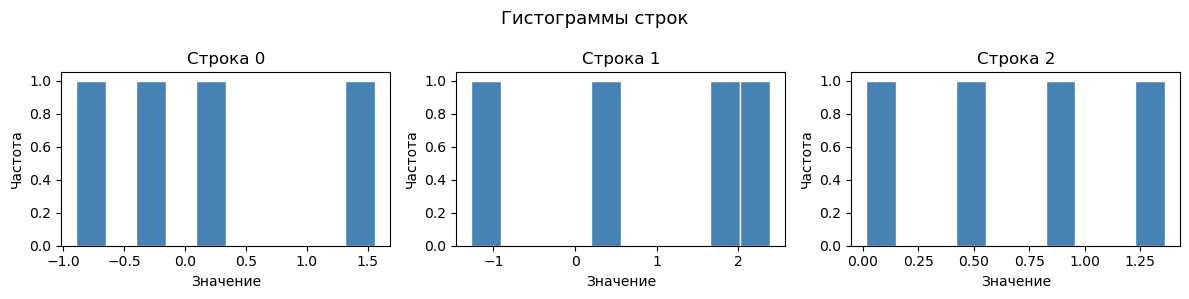

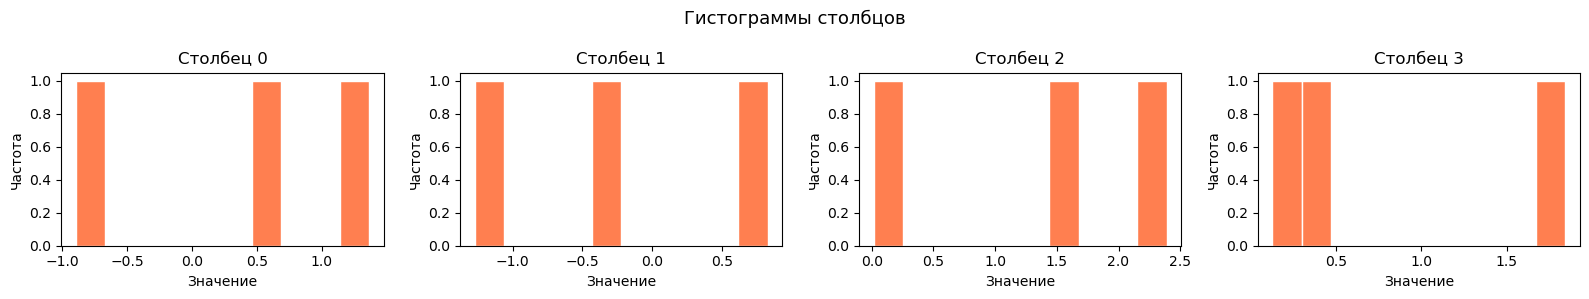

In [16]:
def generate_normal_matrix(m, n, mu=0, sigma=1):
    '''Заполняет матрицу (m, n) числами из N(mu, sigma²).'''
    return np.random.normal(loc=mu, scale=sigma, size=(m, n))

def compute_stats(mat):
    '''
    Считает мат. ожидание и дисперсию по строкам и столбцам.
    Возвращает словарь:
      row_mean, row_var  — массивы длины m
      col_mean, col_var  — массивы длины n
    '''
    return {
        'row_mean': mat.mean(axis=1),
        'row_var' : mat.var(axis=1),
        'col_mean': mat.mean(axis=0),
        'col_var' : mat.var(axis=0),
    }

def plot_histograms(mat, bins=10):
    '''
    Строит гистограммы для каждой строки и каждого столбца матрицы.
    '''
    m, n = mat.shape

    # Гистограммы строк
    fig_rows, axes_rows = plt.subplots(1, m, figsize=(4 * m, 3))
    if m == 1:
        axes_rows = [axes_rows]
    for i, ax in enumerate(axes_rows):
        ax.hist(mat[i], bins=bins, color='steelblue', edgecolor='white')
        ax.set_title(f'Строка {i}')
        ax.set_xlabel('Значение')
        ax.set_ylabel('Частота')
    fig_rows.suptitle('Гистограммы строк', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Гистограммы столбцов
    fig_cols, axes_cols = plt.subplots(1, n, figsize=(4 * n, 3))
    if n == 1:
        axes_cols = [axes_cols]
    for j, ax in enumerate(axes_cols):
        ax.hist(mat[:, j], bins=bins, color='coral', edgecolor='white')
        ax.set_title(f'Столбец {j}')
        ax.set_xlabel('Значение')
        ax.set_ylabel('Частота')
    fig_cols.suptitle('Гистограммы столбцов', fontsize=13)
    plt.tight_layout()
    plt.show()

# Пример использования
if __name__ == "__main__":
    mat = generate_normal_matrix(3, 4, mu=0, sigma=1)
    stats = compute_stats(mat)

    print("=== Статистика по строкам ===")
    for i, (mean, var) in enumerate(zip(stats['row_mean'], stats['row_var'])):
        print(f"Строка {i}: E = {mean:.3f}, D = {var:.3f}")

    print("\n=== Статистика по столбцам ===")
    for j, (mean, var) in enumerate(zip(stats['col_mean'], stats['col_var'])):
        print(f"Столбец {j}: E = {mean:.3f}, D = {var:.3f}")

    plot_histograms(mat)

In [18]:
%%ipytest

# ── Тест 1: форма матрицы ─────────────────────────────────────────────────
def test_matrix_shape():
    mat = generate_normal_matrix(3, 4)
    assert mat.shape == (3, 4)

# ── Тест 2: матрица квадратная ────────────────────────────────────────────
def test_square_matrix():
    mat = generate_normal_matrix(5, 5)
    assert mat.shape == (5, 5)

# ── Тест 3: элементы вещественные ────────────────────────────────────────
def test_dtype_float():
    mat = generate_normal_matrix(3, 3)
    assert np.issubdtype(mat.dtype, np.floating)

# ── Тест 4: нет NaN и Inf ────────────────────────────────────────────────
def test_no_nan_inf():
    mat = generate_normal_matrix(10, 10)
    assert np.isfinite(mat).all()

# ── Тест 5: случайность — две матрицы не совпадают ───────────────────────
def test_randomness():
    A = generate_normal_matrix(5, 5)
    B = generate_normal_matrix(5, 5)
    assert not np.array_equal(A, B)

# ── Тест 6: мат. ожидание близко к mu при большой выборке ────────────────
def test_mean_close_to_mu():
    np.random.seed(0)
    mat = generate_normal_matrix(1, 100_000, mu=3, sigma=1)
    assert abs(mat.mean() - 3) < 0.05

# ── Тест 7: дисперсия близка к sigma² при большой выборке ────────────────
def test_var_close_to_sigma2():
    np.random.seed(0)
    mat = generate_normal_matrix(1, 100_000, mu=0, sigma=2)
    assert abs(mat.var() - 4) < 0.1   # sigma²=4

# ── Тест 8: длина row_mean == m ───────────────────────────────────────────
def test_stats_row_length():
    mat = generate_normal_matrix(4, 6)
    stats = compute_stats(mat)
    assert len(stats['row_mean']) == 4
    assert len(stats['row_var'])  == 4

# ── Тест 9: длина col_mean == n ───────────────────────────────────────────
def test_stats_col_length():
    mat = generate_normal_matrix(4, 6)
    stats = compute_stats(mat)
    assert len(stats['col_mean']) == 6
    assert len(stats['col_var'])  == 6

# ── Тест 10: дисперсия неотрицательна ────────────────────────────────────
def test_variance_nonnegative():
    mat = generate_normal_matrix(5, 5)
    stats = compute_stats(mat)
    assert (stats['row_var'] >= 0).all()
    assert (stats['col_var'] >= 0).all()

# ── Тест 11: ручная проверка compute_stats ────────────────────────────────
def test_compute_stats_manual():
    mat = np.array([[1., 3.],
                    [2., 4.]])
    stats = compute_stats(mat)
    np.testing.assert_allclose(stats['row_mean'], [2., 3.])
    np.testing.assert_allclose(stats['col_mean'], [1.5, 3.5])
    np.testing.assert_allclose(stats['row_var'],  [1., 1.])
    np.testing.assert_allclose(stats['col_var'],  [0.25, 0.25])

# ── Тест 12: plot_histograms не падает ───────────────────────────────────
def test_plot_no_exception(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)  # не открывать окно
    mat = generate_normal_matrix(2, 3)
    plot_histograms(mat)   # просто не должно бросить исключение
    plt.close('all')

............                                                                                 [100%]
12 passed in 0.49s


<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [20]:
def chess(m, n, a, b):
    mat = np.empty((m, n), dtype=type(a))
    # (i+j) % 2 == 0 → a, иначе → b
    rows = np.arange(m).reshape(-1, 1)  # столбец индексов строк
    cols = np.arange(n).reshape(1, -1)  # строка индексов столбцов
    mask = (rows + cols) % 2 == 0       # True там, где должно быть a
    mat[mask]  = a
    mat[~mask] = b
    return mat

In [21]:
%%ipytest

# ── Тест 1: базовый 3×4, проверяем весь результат ────────────────────────
def test_basic_3x4():
    result = chess(3, 4, 0, 1)
    expected = np.array([
        [0, 1, 0, 1],
        [1, 0, 1, 0],
        [0, 1, 0, 1],
    ])
    np.testing.assert_array_equal(result, expected)

# ── Тест 2: левый верхний угол всегда равен a ─────────────────────────────
def test_top_left_is_a():
    assert chess(4, 4, 7, 3)[0, 0] == 7

# ── Тест 3: сосед по диагонали тоже a, по горизонтали/вертикали — b ──────
def test_neighbors():
    mat = chess(3, 3, 10, 20)
    assert mat[0, 0] == 10  # (0,0) → a
    assert mat[0, 1] == 20  # сосед по горизонтали → b
    assert mat[1, 0] == 20  # сосед по вертикали → b
    assert mat[1, 1] == 10  # диагональ → снова a

# ── Тест 4: форма выходной матрицы ───────────────────────────────────────
def test_shape():
    assert chess(5, 7, 0, 1).shape == (5, 7)

# ── Тест 5: матрица 1×1 ───────────────────────────────────────────────────
def test_1x1():
    np.testing.assert_array_equal(chess(1, 1, 5, 9), [[5]])

# ── Тест 6: матрица 1×n (одна строка) ────────────────────────────────────
def test_single_row():
    result = chess(1, 5, 0, 1)
    np.testing.assert_array_equal(result, [[0, 1, 0, 1, 0]])

# ── Тест 7: матрица m×1 (один столбец) ───────────────────────────────────
def test_single_col():
    result = chess(4, 1, 0, 1)
    np.testing.assert_array_equal(result, [[0], [1], [0], [1]])

# ── Тест 8: a == b — вся матрица одинакова ───────────────────────────────
def test_a_equals_b():
    result = chess(3, 3, 5, 5)
    np.testing.assert_array_equal(result, np.full((3, 3), 5))

# ── Тест 9: отрицательные и вещественные значения ────────────────────────
def test_negative_floats():
    result = chess(2, 2, -1.5, 3.7)
    expected = np.array([[-1.5,  3.7],
                         [ 3.7, -1.5]])
    np.testing.assert_array_almost_equal(result, expected)

# ── Тест 10: только два уникальных значения в матрице ────────────────────
def test_only_two_values():
    result = chess(6, 6, 3, 7)
    unique = set(np.unique(result).tolist())
    assert unique == {3, 7}

# ── Тест 11: чётные позиции (i+j чётное) равны a ─────────────────────────
def test_even_positions_are_a():
    m, n, a, b = 4, 5, 42, 0
    result = chess(m, n, a, b)
    rows, cols = np.indices((m, n))
    even_mask = (rows + cols) % 2 == 0
    assert (result[even_mask] == a).all()
    assert (result[~even_mask] == b).all()

...........                                                                                  [100%]
11 passed in 0.11s


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

In [22]:
def draw_rectangle(a, b, m, n,
                   rectangle_color=(255, 0, 0),
                   background_color=(255, 255, 255)):
    '''
    Рисует прямоугольник (a*b) по центру изображения (m*n).
    m, n  — высота и ширина изображения в пикселях
    a, b  — высота и ширина прямоугольника в пикселях
    Цвета задаются кортежами (R, G, B), значения 0–255.
    Возвращает numpy-массив формы (m, n, 3), dtype=uint8.
    '''
    img = np.full((m, n, 3), background_color, dtype=np.uint8)

    # Центрируем прямоугольник
    y0, x0 = m // 2, n // 2
    y_start = max(0, y0 - a // 2)
    y_end   = min(m, y0 + (a - a // 2))
    x_start = max(0, x0 - b // 2)
    x_end   = min(n, x0 + (b - b // 2))

    img[y_start:y_end, x_start:x_end] = rectangle_color

    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Прямоугольник {a}*{b} на холсте {m}*{n}')
    plt.tight_layout()
    plt.show()
    return img


def draw_ellipse(a, b, m, n,
                 ellipse_color=(0, 0, 255),
                 background_color=(255, 255, 255)):
    '''
    Рисует эллипс с полуосями a (вертикальная) и b (горизонтальная)
    по центру изображения (m*n).
    Точка (x, y) попадает внутрь эллипса, если:
        (x - x0)²/b² + (y - y0)²/a² ≤ 1
    Возвращает numpy-массив формы (m, n, 3), dtype=uint8.
    '''
    img = np.full((m, n, 3), background_color, dtype=np.uint8)

    y0, x0 = m // 2, n // 2

    # Сетка координат для всех пикселей сразу (векторизация)
    ys = np.arange(m).reshape(-1, 1)  # (m, 1)
    xs = np.arange(n).reshape(1, -1)  # (1, n)

    mask = ((xs - x0) ** 2) / (b ** 2) + ((ys - y0) ** 2) / (a ** 2) <= 1
    img[mask] = ellipse_color

    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Эллипс a={a}, b={b} на холсте {m}*{n}')
    plt.tight_layout()
    plt.show()
    return img

............                                                                                 [100%]
12 passed in 0.53s


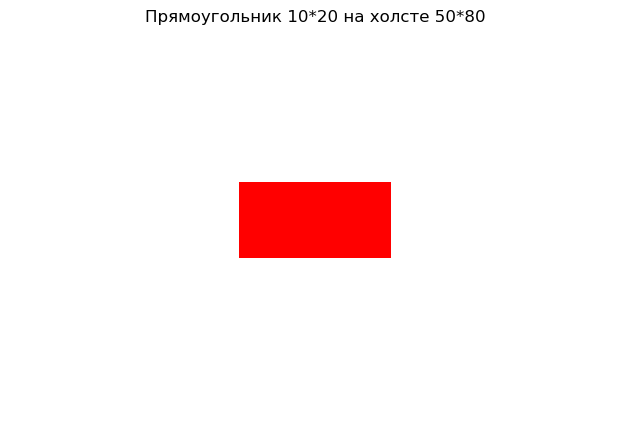

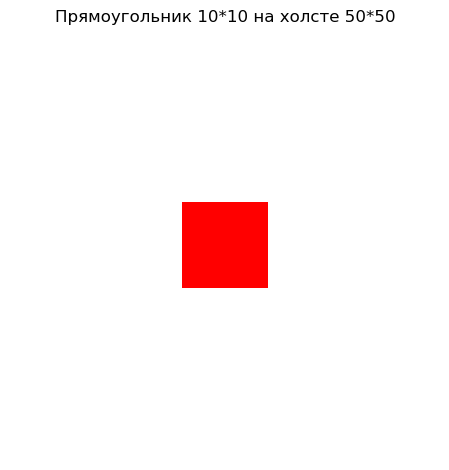

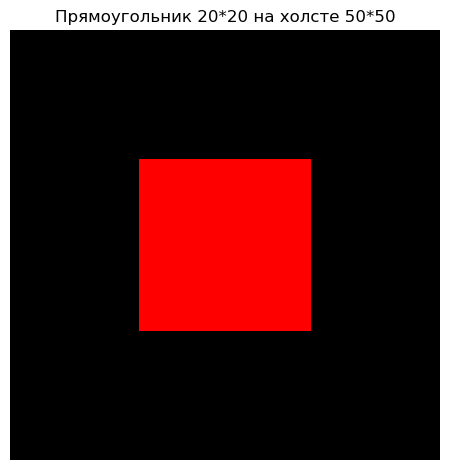

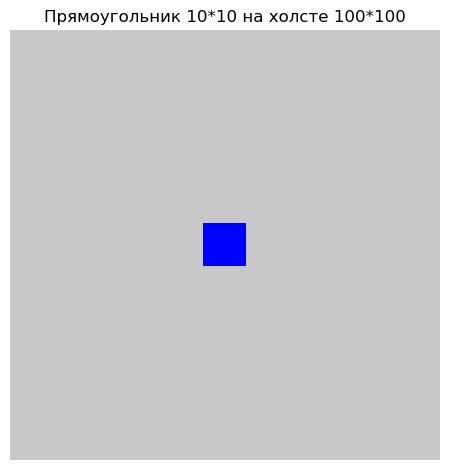

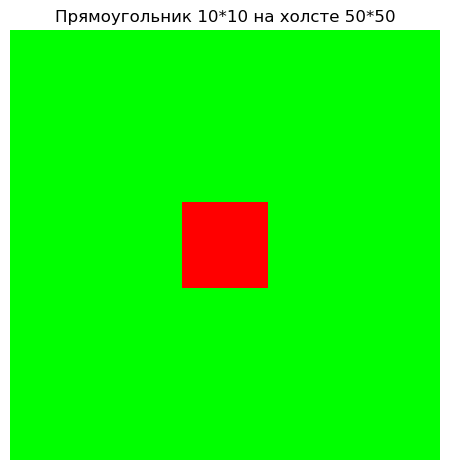

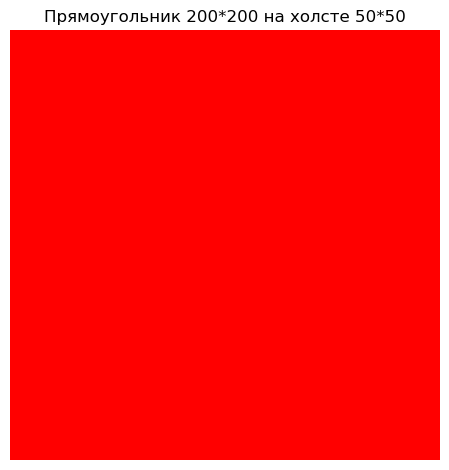

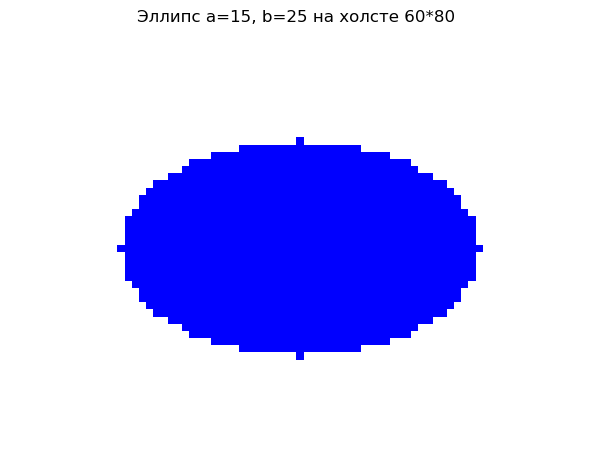

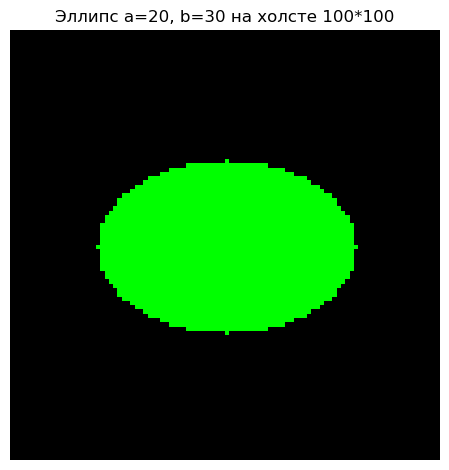

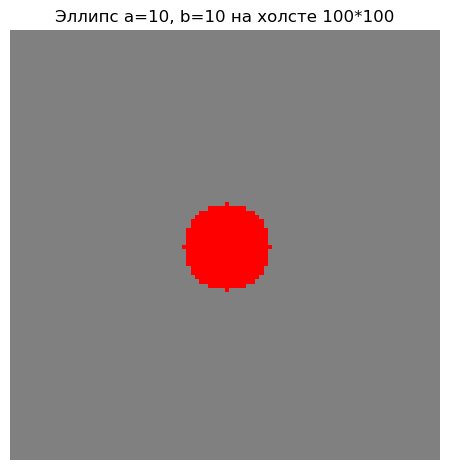

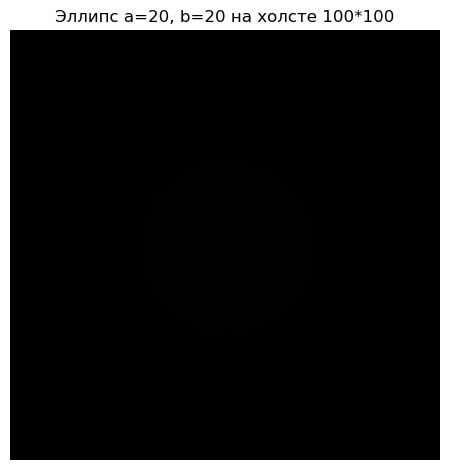

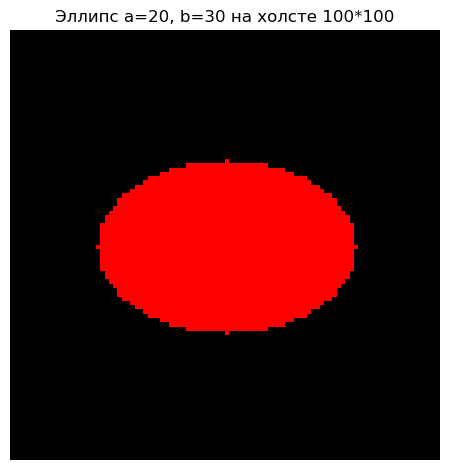

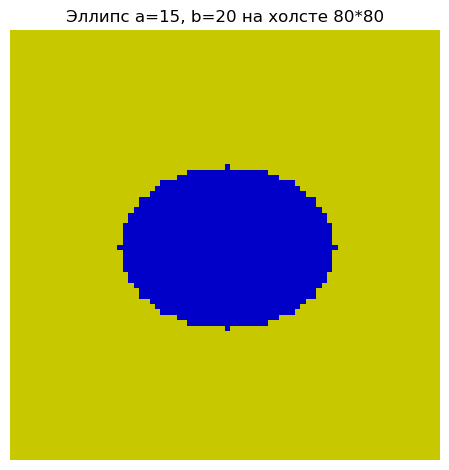

In [23]:
%%ipytest

# ════════════════════════  draw_rectangle  ════════════════════════════════

# ── Тест 1: форма выходного массива ──────────────────────────────────────
def test_rect_shape(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    img = draw_rectangle(10, 20, 50, 80)
    assert img.shape == (50, 80, 3)

# ── Тест 2: dtype uint8 ───────────────────────────────────────────────────
def test_rect_dtype(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    img = draw_rectangle(10, 10, 50, 50)
    assert img.dtype == np.uint8

# ── Тест 3: центр изображения окрашен в цвет прямоугольника ──────────────
def test_rect_center_color(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    rect_color = (255, 0, 0)
    img = draw_rectangle(20, 20, 50, 50, rect_color, (0, 0, 0))
    cy, cx = 25, 25
    np.testing.assert_array_equal(img[cy, cx], rect_color)

# ── Тест 4: углы изображения окрашены в цвет фона ────────────────────────
def test_rect_corners_background(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    bg = (200, 200, 200)
    img = draw_rectangle(10, 10, 100, 100, (0, 0, 255), bg)
    for corner in [(img[0,0]), (img[0,-1]), (img[-1,0]), (img[-1,-1])]:
        np.testing.assert_array_equal(corner, bg)

# ── Тест 5: только два уникальных цвета (фон и прямоугольник) ────────────
def test_rect_two_colors(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    img = draw_rectangle(10, 10, 50, 50, (255, 0, 0), (0, 255, 0))
    pixels = img.reshape(-1, 3)
    unique = {tuple(p) for p in pixels}
    assert unique == {(255, 0, 0), (0, 255, 0)}

# ── Тест 6: прямоугольник не выходит за границы холста ───────────────────
def test_rect_large_rect_clipped(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    img = draw_rectangle(200, 200, 50, 50)  # прямоугольник > холста
    assert img.shape == (50, 50, 3)  # размер не изменился

# ════════════════════════  draw_ellipse  ══════════════════════════════════

# ── Тест 7: форма выходного массива ──────────────────────────────────────
def test_ellipse_shape(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    img = draw_ellipse(15, 25, 60, 80)
    assert img.shape == (60, 80, 3)

# ── Тест 8: центр изображения внутри эллипса ─────────────────────────────
def test_ellipse_center_color(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    ec = (0, 255, 0)
    img = draw_ellipse(20, 30, 100, 100, ec, (0, 0, 0))
    np.testing.assert_array_equal(img[50, 50], ec)

# ── Тест 9: углы изображения снаружи эллипса (цвет фона) ─────────────────
def test_ellipse_corners_background(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    bg = (128, 128, 128)
    img = draw_ellipse(10, 10, 100, 100, (255, 0, 0), bg)
    for corner in [img[0,0], img[0,-1], img[-1,0], img[-1,-1]]:
        np.testing.assert_array_equal(corner, bg)

# ── Тест 10: круг — частный случай эллипса (a == b) ──────────────────────
def test_ellipse_circle_symmetry(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    img = draw_ellipse(20, 20, 100, 100, (1, 1, 1), (0, 0, 0))
    # круг симметричен: img[i, j] == img[j, i] при квадратном холсте
    np.testing.assert_array_equal(img, img.transpose(1, 0, 2))

# ── Тест 11: точки на границе (≤1) внутри эллипса ────────────────────────
def test_ellipse_boundary_included(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    a, b, m, n = 20, 30, 100, 100
    ec = (255, 0, 0)
    img = draw_ellipse(a, b, m, n, ec, (0, 0, 0))
    cy, cx = m // 2, n // 2
    # конец полуоси a — ровно на границе эллипса по вертикали
    np.testing.assert_array_equal(img[cy + a, cx], ec)

# ── Тест 12: только два уникальных цвета в эллипсе ───────────────────────
def test_ellipse_two_colors(monkeypatch):
    monkeypatch.setattr(plt, 'show', lambda: None)
    img = draw_ellipse(15, 20, 80, 80, (0, 0, 200), (200, 200, 0))
    unique = {tuple(p) for p in img.reshape(-1, 3)}
    assert unique == {(0, 0, 200), (200, 200, 0)}

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

E=-6.405  D=21.351  σ=4.621
Локальных максимумов: 27
Локальных минимумов:  27
Скользящее среднее (p=10): длина=91


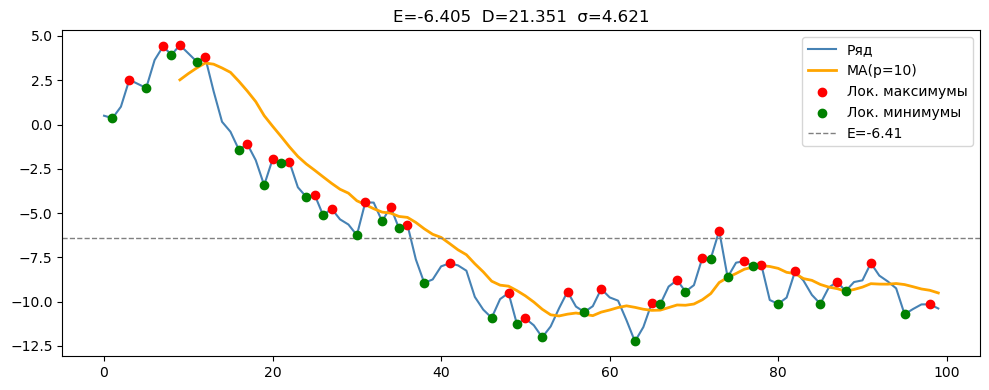

In [24]:
def ts_stats(series):
    '''
    Считает основные статистики временного ряда.
    Возвращает словарь: mean, var, std.
    '''
    s = np.asarray(series, dtype=float)
    return {
        'mean': s.mean(),
        'var' : s.var(),
        'std' : s.std(),
    }


def local_extrema(series):
    '''
    Находит локальные максимумы и минимумы временного ряда.
    Локальный максимум: s[i] > s[i-1] и s[i] > s[i+1]
    Локальный минимум:  s[i] < s[i-1] и s[i] < s[i+1]
    Крайние точки (i=0 и i=N-1) не рассматриваются.
    Возвращает словарь:
      max_idx, max_val — индексы и значения максимумов
      min_idx, min_val — индексы и значения минимумов
    '''
    s = np.asarray(series, dtype=float)
    left  = s[:-2]   # s[i-1]
    mid   = s[1:-1]  # s[i]
    right = s[2:]    # s[i+1]

    max_mask = (mid > left) & (mid > right)
    min_mask = (mid < left) & (mid < right)

    # +1 — сдвиг обратно к исходным индексам
    max_idx = np.where(max_mask)[0] + 1
    min_idx = np.where(min_mask)[0] + 1

    return {
        'max_idx': max_idx,
        'max_val': s[max_idx],
        'min_idx': min_idx,
        'min_val': s[min_idx],
    }


def moving_average(series, p):
    '''
    Скользящее среднее с окном p.
    Возвращает массив длины len(series) - p + 1:
    каждый элемент — среднее p последовательных значений.
    '''
    s = np.asarray(series, dtype=float)
    if p < 1 or p > len(s):
        raise ValueError(f"Размер окна p={p} должен быть в диапазоне [1, {len(s)}]")
    # np.convolve с ядром 1/p даёт скользящее среднее
    kernel = np.ones(p) / p
    return np.convolve(s, kernel, mode='valid')


def plot_timeseries(series, p=5):
    '''Визуализирует ряд, экстремумы и скользящее среднее.'''
    s = np.asarray(series, dtype=float)
    ext = local_extrema(s)
    ma  = moving_average(s, p)
    stats = ts_stats(s)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(s, label='Ряд', color='steelblue', linewidth=1.5)
    ax.plot(np.arange(p - 1, len(s)), ma,
            label=f'MA(p={p})', color='orange', linewidth=2)
    ax.scatter(ext['max_idx'], ext['max_val'],
               color='red', zorder=5, label='Лок. максимумы')
    ax.scatter(ext['min_idx'], ext['min_val'],
               color='green', zorder=5, label='Лок. минимумы')
    ax.axhline(stats['mean'], color='gray', linestyle='--',
               linewidth=1, label=f'E={stats["mean"]:.2f}')
    ax.set_title(f'E={stats["mean"]:.3f}  D={stats["var"]:.3f}  σ={stats["std"]:.3f}')
    ax.legend()
    plt.tight_layout()
    plt.show()


# ── Пример использования ─────────────────────────────────────────────────
np.random.seed(42)
series = np.cumsum(np.random.randn(100))  # случайное блуждание

stats = ts_stats(series)
print(f"E={stats['mean']:.3f}  D={stats['var']:.3f}  σ={stats['std']:.3f}")

ext = local_extrema(series)
print(f"Локальных максимумов: {len(ext['max_idx'])}")
print(f"Локальных минимумов:  {len(ext['min_idx'])}")

ma = moving_average(series, p=10)
print(f"Скользящее среднее (p=10): длина={len(ma)}")

plot_timeseries(series, p=10)

In [25]:
%%ipytest

# ════════════════════════  ts_stats  ══════════════════════════════════════

# ── Тест 1: ручная проверка mean, var, std ────────────────────────────────
def test_stats_manual():
    s = [2., 4., 4., 4., 5., 5., 7., 9.]
    stats = ts_stats(s)
    assert abs(stats['mean'] - 5.0)  < 1e-10
    assert abs(stats['var']  - 4.0)  < 1e-10
    assert abs(stats['std']  - 2.0)  < 1e-10

# ── Тест 2: константный ряд → var=0, std=0 ────────────────────────────────
def test_stats_constant():
    stats = ts_stats([7, 7, 7, 7])
    assert stats['var'] == 0
    assert stats['std'] == 0

# ── Тест 3: std == sqrt(var) всегда ───────────────────────────────────────
def test_stats_std_sqrt_var():
    np.random.seed(0)
    s = np.random.randn(50)
    stats = ts_stats(s)
    assert abs(stats['std'] - np.sqrt(stats['var'])) < 1e-12

# ── Тест 4: var неотрицательна ────────────────────────────────────────────
def test_stats_var_nonneg():
    assert ts_stats(np.random.randn(30))['var'] >= 0

# ════════════════════════  local_extrema  ════════════════════════════════

# ── Тест 5: простой ряд с известными экстремумами ─────────────────────────
def test_extrema_basic():
    s = [1, 3, 2, 5, 1, 4, 2]
    ext = local_extrema(s)
    #  максимумы: индексы 1(=3), 3(=5), 5(=4)
    #  минимумы:  индексы 2(=2), 4(=1)
    np.testing.assert_array_equal(ext['max_idx'], [1, 3, 5])
    np.testing.assert_array_equal(ext['min_idx'], [2, 4])

# ── Тест 6: значения в экстремумах совпадают с исходным рядом ────────────
def test_extrema_values():
    s = np.array([1, 3, 2, 5, 1, 4, 2], dtype=float)
    ext = local_extrema(s)
    np.testing.assert_array_equal(ext['max_val'], s[ext['max_idx']])
    np.testing.assert_array_equal(ext['min_val'], s[ext['min_idx']])

# ── Тест 7: монотонный ряд — нет экстремумов ─────────────────────────────
def test_extrema_monotone():
    ext = local_extrema([1, 2, 3, 4, 5])
    assert len(ext['max_idx']) == 0
    assert len(ext['min_idx']) == 0

# ── Тест 8: крайние точки не считаются экстремумами ──────────────────────
def test_extrema_no_boundary():
    ext = local_extrema([10, 1, 2, 1, 10])
    assert 0  not in ext['max_idx']
    assert 4  not in ext['max_idx']

# ── Тест 9: максимум всегда больше своих соседей ─────────────────────────
def test_extrema_max_gt_neighbors():
    s = np.array([1, 5, 2, 8, 3, 6, 1], dtype=float)
    ext = local_extrema(s)
    for i in ext['max_idx']:
        assert s[i] > s[i - 1] and s[i] > s[i + 1]

# ════════════════════════  moving_average  ═══════════════════════════════

# ── Тест 10: длина результата == len(s) - p + 1 ───────────────────────────
def test_ma_length():
    s = list(range(10))
    assert len(moving_average(s, 3)) == 8
    assert len(moving_average(s, 1)) == 10
    assert len(moving_average(s, 10)) == 1

# ── Тест 11: ручная проверка значений ────────────────────────────────────
def test_ma_values():
    s = [1, 2, 3, 4, 5]
    ma = moving_average(s, 3)
    np.testing.assert_array_almost_equal(ma, [2., 3., 4.])

# ── Тест 12: p=1 → MA совпадает с исходным рядом ─────────────────────────
def test_ma_p1_identity():
    s = [3, 1, 4, 1, 5]
    np.testing.assert_array_almost_equal(moving_average(s, 1), s)

# ── Тест 13: константный ряд → MA равно той же константе ─────────────────
def test_ma_constant():
    s = [5] * 10
    np.testing.assert_array_almost_equal(moving_average(s, 4),
                                         [5.] * 7)

.............                                                                                [100%]
13 passed in 0.12s


<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]